In [1]:
from pathlib import Path
from os import environ

try:
  import google.colab
  IN_COLAB = True

  # Cell 1 (Colab only - skip locally)
  !git clone https://github.com/RealAshrafAhmed/waterloo-slt-reading-group.git /content/repo
  %cd /content/repo
  !pip install uv && uv sync --all-packages
  # Cell 2 (both environments)
  from colab_extensions.env import setup
  env = setup()
  ROOT, DATA, OUTPUTS = env["ROOT"], env["DATA"], env["OUTPUTS"]
except ImportError:
  IN_COLAB = False
  if "DRIVE_HOME" in environ:
    ROOT = Path(f"{environ.get("DRIVE_HOME")}/colab/outputs/waterloo-slt-reading-group")
  else:
    ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
  basedir = Path(f"{ROOT}/mixture/poisson2d")
  datadir = Path(f"{basedir}/data")
  outputdir = Path(f"{basedir}/tempered")


if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/tempered


In [2]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [3]:
def find_truth_by_dsid(dsid: str):
    dgp = dgps.query(f"dsid=='{dsid}'")
    truth = dgp[["m0", "m1", "w0", "w1"]].iloc[0].tolist()
    return truth

In [4]:
import numpy as np
regimes = np.array([50, 250, 5000])
target_beta = 1/np.sqrt(regimes)
print(target_beta)

[0.14142136 0.06324555 0.01414214]


In [5]:
beta_data = {}
for i, ivalue in enumerate(regimes):
  beta_data[i] = np.ones(len(target_beta))
  for j, jvalue in enumerate(target_beta):
    beta_data[i][j] = target_beta[i]/jvalue

print(beta_data)

{0: array([ 1.        ,  2.23606798, 10.        ]), 1: array([0.4472136 , 1.        , 4.47213595]), 2: array([0.1      , 0.2236068, 1.       ])}


In [39]:
from pymc_extensions.tempered_mixpoisson import TemperedPoissonMixture
from tqdm.notebook import tqdm
import pymc as pm
import numpy as np
import arviz as az

n_components = 2

# mcmc settings
n_draws = 1000
n_tune = 2500

tempered_posterior_data = {}

for dsid in tqdm(dgps["dsid"].unique(), desc=f"class "):
  tempered_posterior_data[dsid] = {}
  for regime_index, regime in enumerate(tqdm(regimes, desc=f"dsid={dsid}, regime ")):
    tempered_posterior_data[dsid][regime] = {}
    dataset = pd.read_csv(f"{datadir}/{dsid}-{regime}.csv")
    X = dataset.iloc[:, 0].to_numpy()
    n_obs = len(X)
    # powers = [1, 0.5*np.sqrt(n_obs)/2, np.sqrt(n_obs), 2*np.sqrt(n_obs)]
    # betas= [1/p for p in powers]
    betas = beta_data[regime_index]

    for beta_index, beta in enumerate(tqdm(betas, desc=f"dsid={dsid}, regime={regime}")):
      tempered_posterior_data_file = Path(f"{outputdir}/tempered-posterior-{dsid}-{regime}-beta-{beta:.3f}.nc")
      
      # if tempered_posterior_data_file.exists(): # check if this data has already been generated
        # idata = az.from_netcdf(tempered_posterior_data_file)
        # print(f"Loaded tempered (beta={beta}) posterior data from {tempered_posterior_data_file}!")
      # else:
      with TemperedPoissonMixture(X=X, beta=beta, mus_log_prior_sigma=2) as model:
        idata = model.sample(draws=n_draws, tune=n_tune, chains=3)  # or "blackjax"
        idata.to_netcdf(tempered_posterior_data_file)
        print(f"File {tempered_posterior_data_file} created!.")
        tempered_posterior_data[dsid][regime][beta]=idata

class :   0%|          | 0/4 [00:00<?, ?it/s]

dsid=regular, regime :   0%|          | 0/3 [00:00<?, ?it/s]

dsid=regular, regime=50:   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

...

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/tempered/tempered-posterior-singular2-5000-beta-1.000.nc created!.


In [40]:
# put the posteriors in a dataframe for easy visualization
joined_posterior_data = []
for dsid, dd in tempered_posterior_data.items():
    truth = find_truth_by_dsid(dsid=dsid)
    # dgp_weights = dgp[["w0", "w1"]].iloc[0].tolist()
    # dgp_mus = dgp[["m0", "m1"]].iloc[0].tolist()
    # truth = np.concatenate([dgp_mus, dgp_weights])
    for ss in regimes:
      regime_data = dd[ss]
      for ibeta, beta in enumerate(list(regime_data.keys())):
        idata = regime_data[beta]
        param_samples = az.extract(idata, var_names=["weights", "mus"])
        n_draws = param_samples.sizes["sample"]
        joined_posterior_data.append({
          "w0": param_samples["weights"][0,].values,
          "m0": param_samples["mus"][0,].values,
          "m1": param_samples["mus"][1,].values,
          "n": np.repeat(ss, n_draws),
          "beta": np.repeat(beta, n_draws),
          "ibeta": np.repeat(ibeta, n_draws),
          "dsid": np.repeat(dsid, n_draws)
        })

joined_posterior_df = pd.concat([pd.DataFrame(d) for d in joined_posterior_data], ignore_index=True)
joined_posterior_df.head()

,w0,m0,m1,n,beta,ibeta,dsid
0,0.363623,0.867072,15.200288,50,1.0,0,regular
1,0.239548,1.360168,14.314308,50,1.0,0,regular
2,0.276363,1.487359,15.304798,50,1.0,0,regular
3,0.295381,1.199370,14.600853,50,1.0,0,regular
4,0.312569,1.202503,14.608207,50,1.0,0,regular


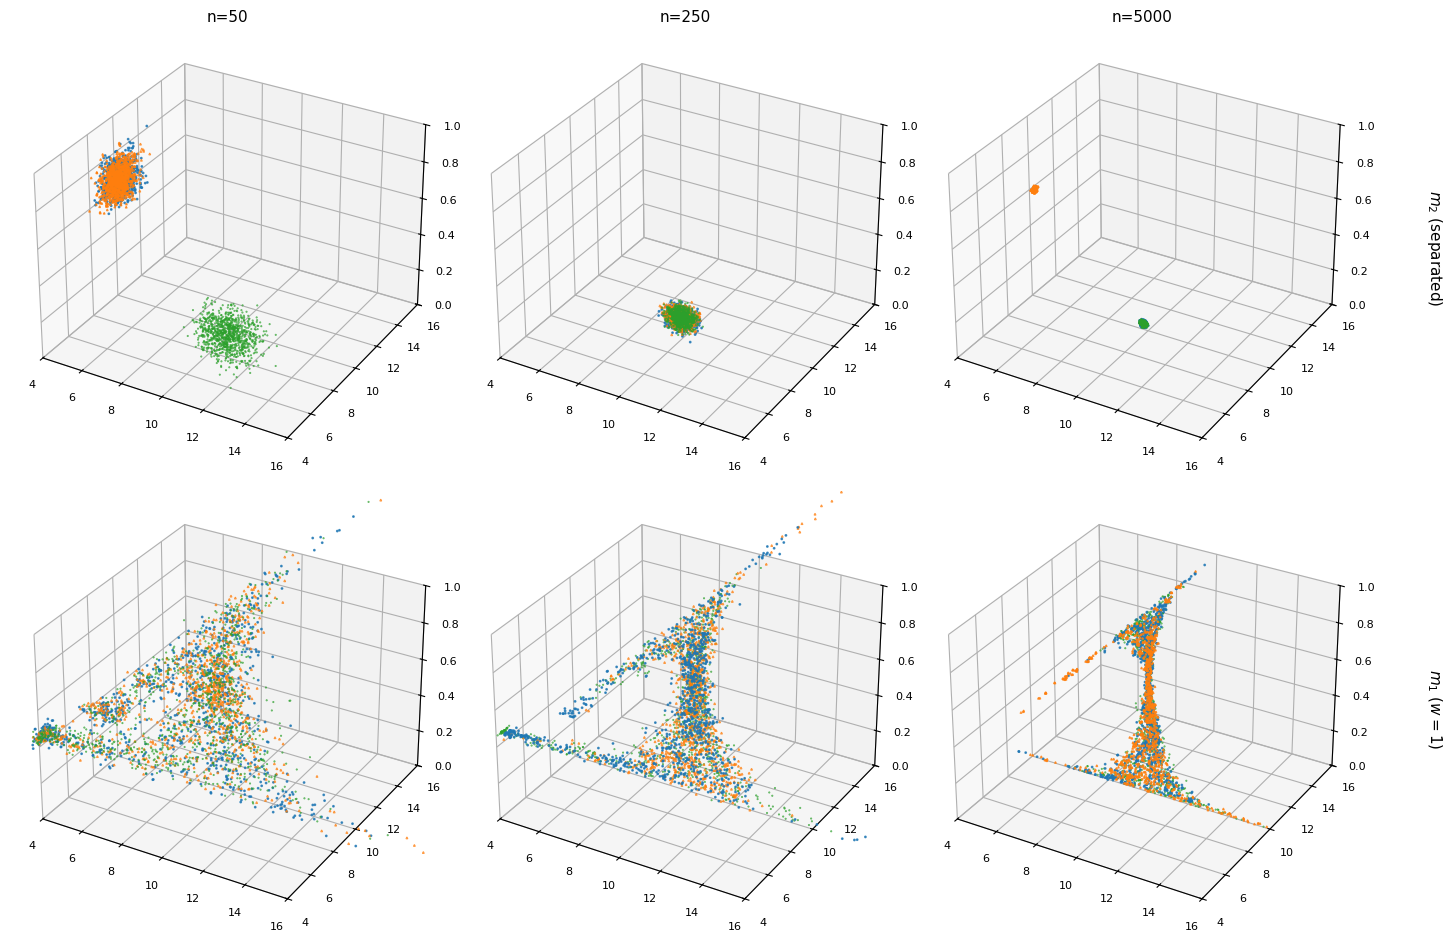

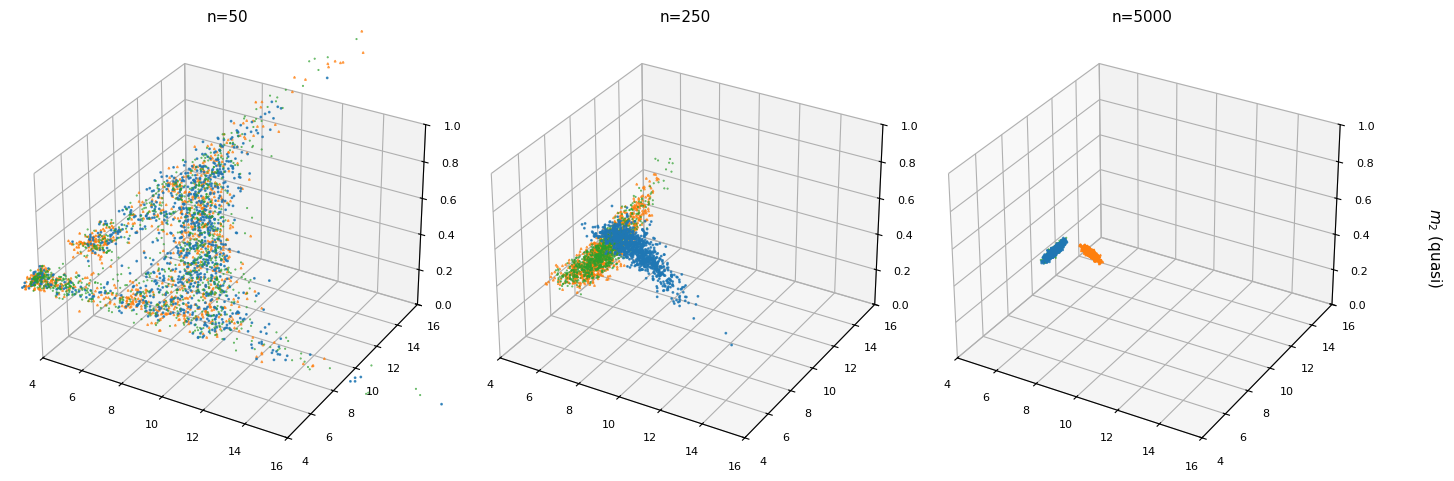

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ (separated)',
    'e-singular': r'$m_2$ (quasi)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($p_0=p_1$)',
}

# Choose which beta to plot (e.g., beta=1 for untempered)
plot_beta = 1

n_regimes = len(regimes)

# --- Plot 1: Regular and Singular ---
reg_sing_dsids = ['regular', 'singular1']
reg_sing_dsids = [d for d in reg_sing_dsids if d in tempered_posterior_data]

fig1, axes1 = plt.subplots(len(reg_sing_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(reg_sing_dsids)), 
                            subplot_kw={'projection': '3d'})
if len(reg_sing_dsids) == 1:
    axes1 = axes1.reshape(1, -1)

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

markers = ['o', '^', '.', '+']

for i, dsid in enumerate(reg_sing_dsids):
    for j, regime in enumerate(regimes):
        idata = tempered_posterior_data[dsid][regime][plot_beta]
        n_chains = idata.posterior.sizes["chain"]
        
        for chain in range(n_chains):
            w = idata.posterior["weights"][chain, :, 0]
            p0 = idata.posterior["mus"][chain, :, 0]
            p1 = idata.posterior["mus"][chain, :, 1]
            axes1[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
        
        # Zoom in
        axes1[i, j].set_xlim(4, 16)
        axes1[i, j].set_ylim(4, 16)
        axes1[i, j].set_zlim(0, 1)
        
        # Original default angle
        axes1[i, j].view_init(elev=30, azim=-60)
        
        axes1[i, j].tick_params(labelsize=8)
        
        # Column titles only on top row
        if i == 0:
            axes1[i, j].set_title(f'n={regime}', fontsize=11)

# Add row labels on the right side
for i, dsid in enumerate(reg_sing_dsids):
    ax = axes1[i, -1]
    ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
              transform=ax.transAxes, 
              rotation=270, 
              va='center', 
              fontsize=11)

# fig1.suptitle('Regular and Singular Posterior Geometry', fontsize=14, y=0.96)
fig1.savefig(Path(f"{outputdir}/3d_view_reg_sing.png"), dpi=600, bbox_inches="tight")
plt.show()


# --- Plot 2: Quasi-singular ---
quasi_dsids = ['e-singular']
quasi_dsids = [d for d in quasi_dsids if d in tempered_posterior_data]

if quasi_dsids:
    fig2, axes2 = plt.subplots(len(quasi_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(quasi_dsids)), 
                                subplot_kw={'projection': '3d'})
    if len(quasi_dsids) == 1:
        axes2 = axes2.reshape(1, -1)

    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

    for i, dsid in enumerate(quasi_dsids):
        for j, regime in enumerate(regimes):
            idata = tempered_posterior_data[dsid][regime][plot_beta]
            n_chains = idata.posterior.sizes["chain"]
            
            for chain in range(n_chains):
                w = idata.posterior["weights"][chain, :, 0]
                p0 = idata.posterior["mus"][chain, :, 0]
                p1 = idata.posterior["mus"][chain, :, 1]
                axes2[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
            
            # Zoom in
            axes2[i, j].set_xlim(4, 16)
            axes2[i, j].set_ylim(4, 16)
            axes2[i, j].set_zlim(0, 1)
            
            # Original default angle
            axes2[i, j].view_init(elev=30, azim=-60)
            
            axes2[i, j].tick_params(labelsize=8)
            
            # Column titles only on top row
            if i == 0:
                axes2[i, j].set_title(f'n={regime}', fontsize=11)

    # Add row labels on the right side
    for i, dsid in enumerate(quasi_dsids):
        ax = axes2[i, -1]
        ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
                  transform=ax.transAxes, 
                  rotation=270, 
                  va='center', 
                  fontsize=11)

    # fig2.suptitle('Quasi-Singular Posterior Geometry', fontsize=14, y=0.96)
    fig2.savefig(Path(f"{outputdir}/3d_view_quasi.png"), dpi=600, bbox_inches="tight")
    plt.show()

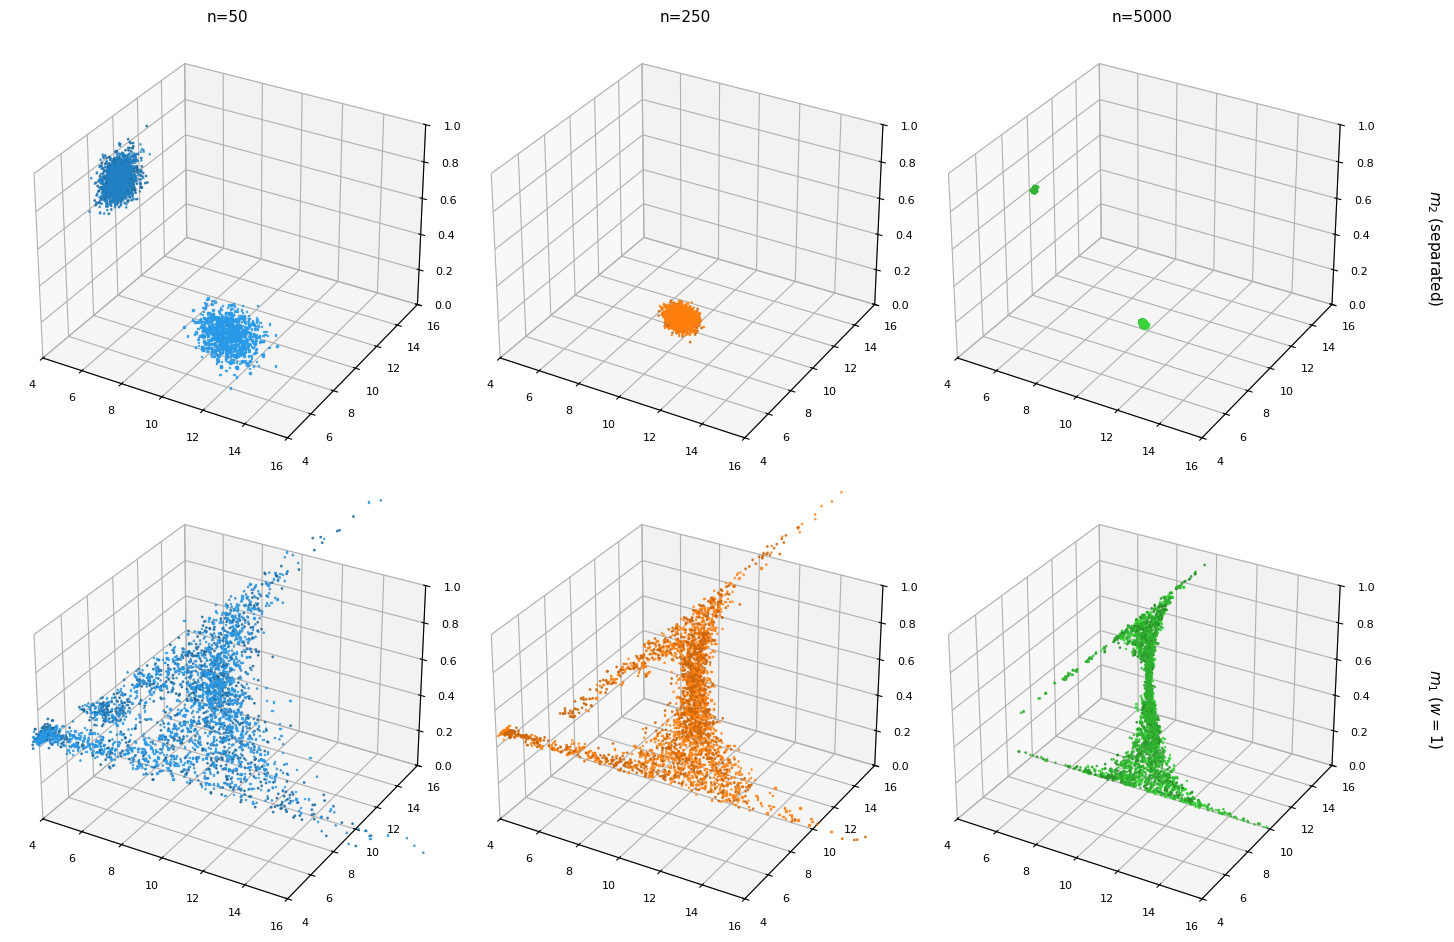

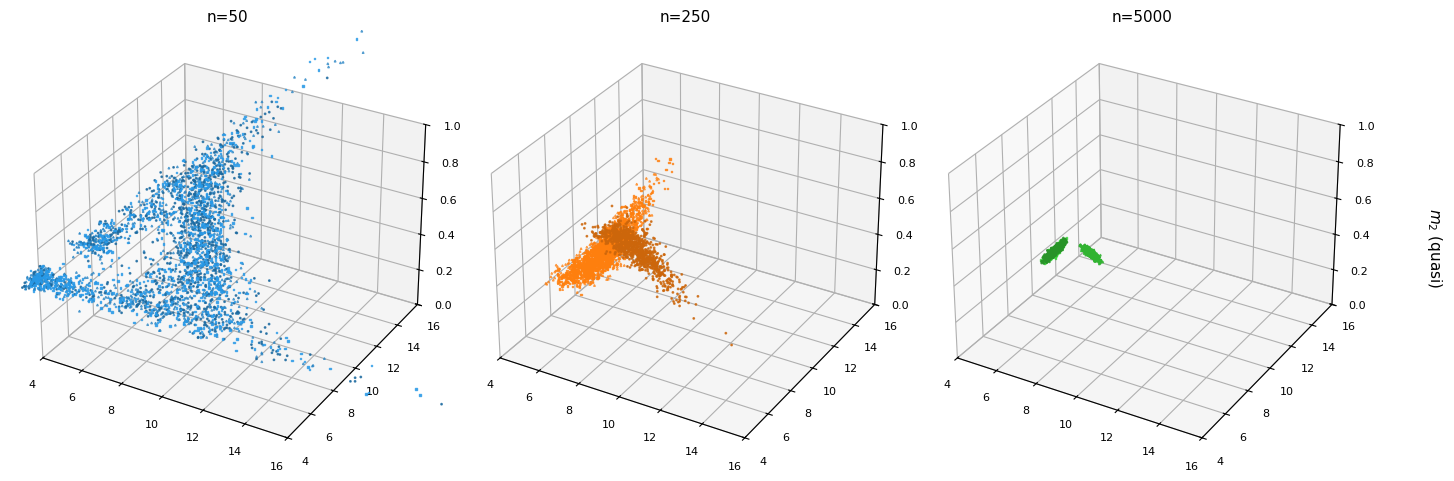

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ (separated)',
    'e-singular': r'$m_2$ (quasi)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($p_0=p_1$)',
}

# Choose which beta to plot (e.g., beta=1 for untempered)
plot_beta = 1

n_regimes = len(regimes)

# Use seaborn's default palette for base colors
default_palette = sns.color_palette()
base_colors = {
    50: default_palette[0],      # blue
    250: default_palette[1],     # orange
    5000: default_palette[2],    # green
}

# Function to create shades of a color
def get_shades(base_color, n_shades):
    """Create n_shades variations of base_color from lighter to darker"""
    # Convert to HSV, vary the saturation/value
    rgb = mcolors.to_rgb(base_color)
    hsv = mcolors.rgb_to_hsv(rgb)
    shades = []
    for i in range(n_shades):
        # Vary value from 0.6 to 1.0
        factor = 0.6 + 0.4 * (i / max(n_shades - 1, 1))
        new_hsv = (hsv[0], hsv[1], min(hsv[2] * factor + 0.2, 1.0))
        shades.append(mcolors.hsv_to_rgb(new_hsv))
    return shades

# --- Plot 1: Regular and Singular ---
reg_sing_dsids = ['regular', 'singular1']
reg_sing_dsids = [d for d in reg_sing_dsids if d in tempered_posterior_data]

fig1, axes1 = plt.subplots(len(reg_sing_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(reg_sing_dsids)), 
                            subplot_kw={'projection': '3d'})
if len(reg_sing_dsids) == 1:
    axes1 = axes1.reshape(1, -1)

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

markers = ['o', '^', 's', '+']

for i, dsid in enumerate(reg_sing_dsids):
    for j, regime in enumerate(regimes):
        idata = tempered_posterior_data[dsid][regime][plot_beta]
        n_chains = idata.posterior.sizes["chain"]
        
        # Get shades of the color for this sample size
        base_color = base_colors.get(regime, 'gray')
        shades = get_shades(base_color, n_chains)
        
        for chain in range(n_chains):
            w = idata.posterior["weights"][chain, :, 0]
            p0 = idata.posterior["mus"][chain, :, 0]
            p1 = idata.posterior["mus"][chain, :, 1]
            axes1[i, j].scatter(p0, p1, w, marker=markers[chain % len(markers)], 
                               s=1, alpha=0.8, color=shades[chain])
        
        # Zoom in
        axes1[i, j].set_xlim(4, 16)
        axes1[i, j].set_ylim(4, 16)
        axes1[i, j].set_zlim(0, 1)
        
        # Original default angle
        axes1[i, j].view_init(elev=30, azim=-60)
        
        axes1[i, j].tick_params(labelsize=8)
        
        # Column titles only on top row
        if i == 0:
            axes1[i, j].set_title(f'n={regime}', fontsize=11)

# Add row labels on the right side
for i, dsid in enumerate(reg_sing_dsids):
    ax = axes1[i, -1]
    ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
              transform=ax.transAxes, 
              rotation=270, 
              va='center', 
              fontsize=11)

# fig1.suptitle('Regular and Singular Posterior Geometry', fontsize=14, y=0.96)
fig1.savefig(Path(f"{outputdir}/3d_view_reg_sing.png"), dpi=600, bbox_inches="tight")
plt.show()


# --- Plot 2: Quasi-singular ---
quasi_dsids = ['e-singular']
quasi_dsids = [d for d in quasi_dsids if d in tempered_posterior_data]

if quasi_dsids:
    fig2, axes2 = plt.subplots(len(quasi_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(quasi_dsids)), 
                                subplot_kw={'projection': '3d'})
    if len(quasi_dsids) == 1:
        axes2 = axes2.reshape(1, -1)

    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

    for i, dsid in enumerate(quasi_dsids):
        for j, regime in enumerate(regimes):
            idata = tempered_posterior_data[dsid][regime][plot_beta]
            n_chains = idata.posterior.sizes["chain"]
            
            # Get shades of the color for this sample size
            base_color = base_colors.get(regime, 'gray')
            shades = get_shades(base_color, n_chains)
            
            for chain in range(n_chains):
                w = idata.posterior["weights"][chain, :, 0]
                p0 = idata.posterior["mus"][chain, :, 0]
                p1 = idata.posterior["mus"][chain, :, 1]
                axes2[i, j].scatter(p0, p1, w, marker=markers[chain % len(markers)], 
                                   s=1, alpha=0.8, color=shades[chain])
            
            # Zoom in
            axes2[i, j].set_xlim(4, 16)
            axes2[i, j].set_ylim(4, 16)
            axes2[i, j].set_zlim(0, 1)
            
            # Original default angle
            axes2[i, j].view_init(elev=30, azim=-60)
            
            axes2[i, j].tick_params(labelsize=8)
            
            # Column titles only on top row
            if i == 0:
                axes2[i, j].set_title(f'n={regime}', fontsize=11)

    # Add row labels on the right side
    for i, dsid in enumerate(quasi_dsids):
        ax = axes2[i, -1]
        ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
                  transform=ax.transAxes, 
                  rotation=270, 
                  va='center', 
                  fontsize=11)

    # fig2.suptitle('Quasi-Singular Posterior Geometry', fontsize=14, y=0.96)
    fig2.savefig(Path(f"{outputdir}/3d_view_quasi.png"), dpi=600, bbox_inches="tight")
    plt.show()

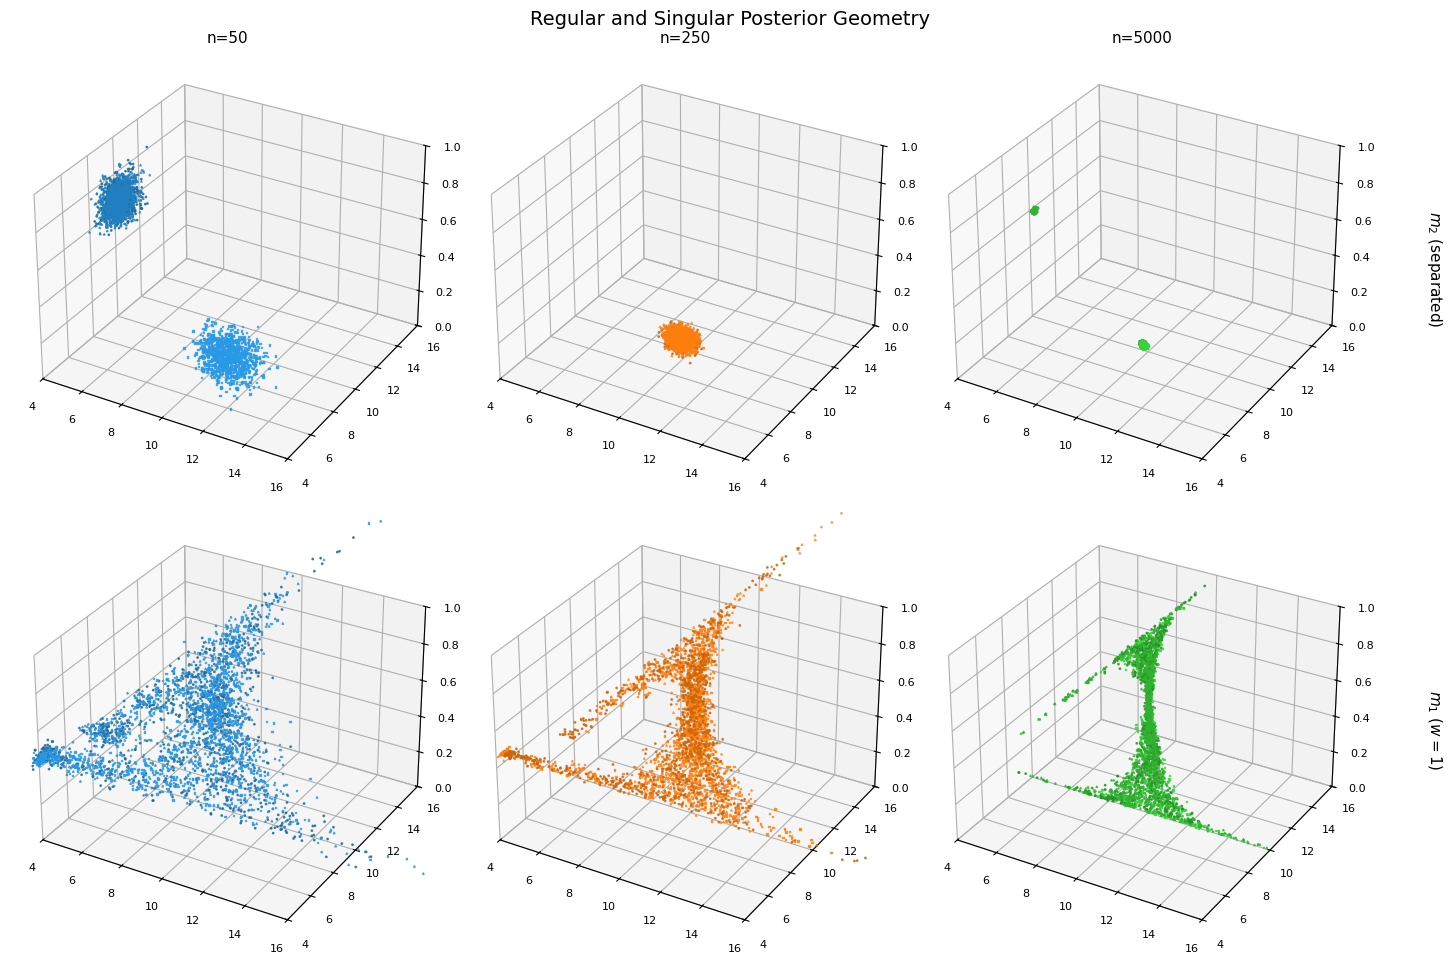

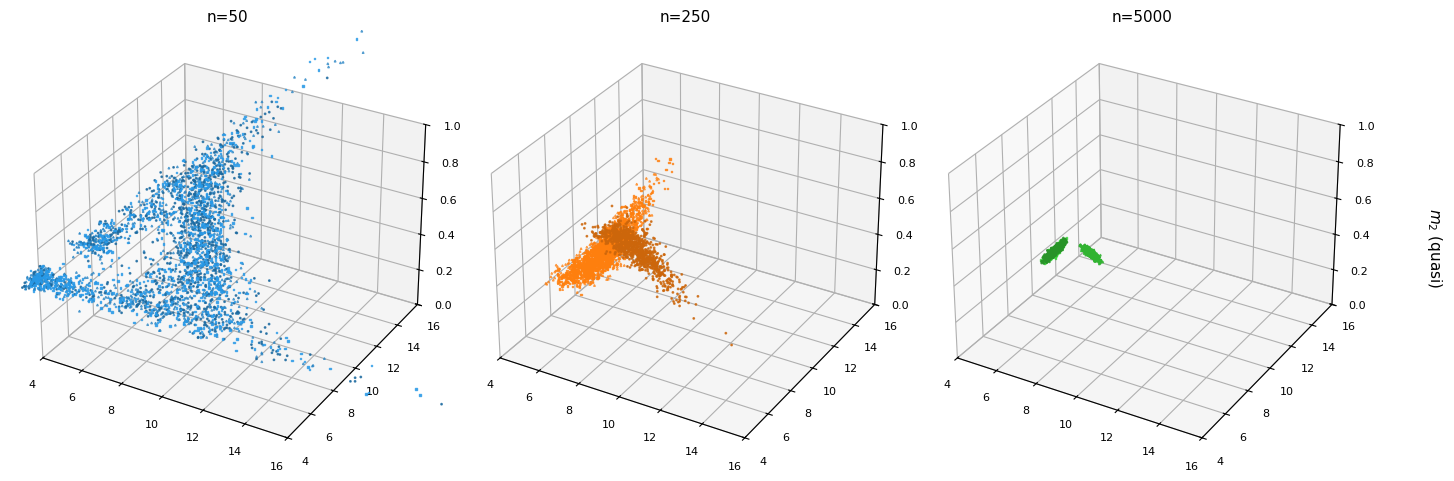

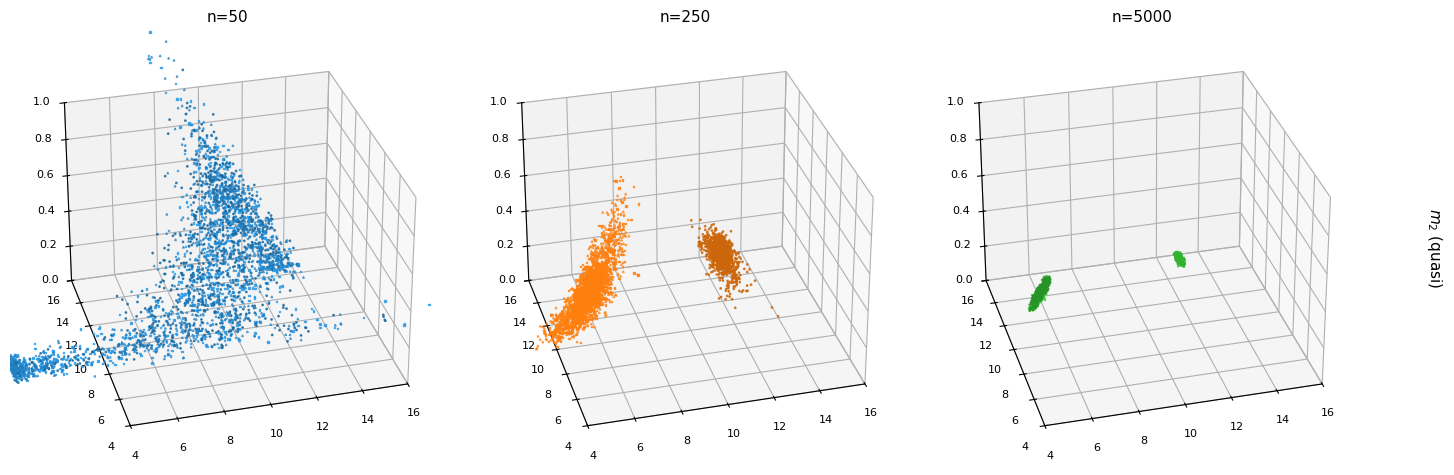

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ (separated)',
    'e-singular': r'$m_2$ (quasi)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($p_0=p_1$)',
}

# Choose which beta to plot (e.g., beta=1 for untempered)
plot_beta = 1

n_regimes = len(regimes)

# Use seaborn's default palette for base colors
default_palette = sns.color_palette()
base_colors = {
    50: default_palette[0],      # blue
    250: default_palette[1],     # orange
    5000: default_palette[2],    # green
}

# Function to create shades of a color
def get_shades(base_color, n_shades):
    """Create n_shades variations of base_color from lighter to darker"""
    rgb = mcolors.to_rgb(base_color)
    hsv = mcolors.rgb_to_hsv(rgb)
    shades = []
    for i in range(n_shades):
        factor = 0.6 + 0.4 * (i / max(n_shades - 1, 1))
        new_hsv = (hsv[0], hsv[1], min(hsv[2] * factor + 0.2, 1.0))
        shades.append(mcolors.hsv_to_rgb(new_hsv))
    return shades

markers = ['o', '^', 's', '+']

# --- Plot 1: Regular and Singular ---
reg_sing_dsids = ['regular', 'singular1']
reg_sing_dsids = [d for d in reg_sing_dsids if d in tempered_posterior_data]

fig1, axes1 = plt.subplots(len(reg_sing_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(reg_sing_dsids)), 
                            subplot_kw={'projection': '3d'})
if len(reg_sing_dsids) == 1:
    axes1 = axes1.reshape(1, -1)

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

for i, dsid in enumerate(reg_sing_dsids):
    for j, regime in enumerate(regimes):
        idata = tempered_posterior_data[dsid][regime][plot_beta]
        n_chains = idata.posterior.sizes["chain"]
        
        base_color = base_colors.get(regime, 'gray')
        shades = get_shades(base_color, n_chains)
        
        for chain in range(n_chains):
            w = idata.posterior["weights"][chain, :, 0]
            p0 = idata.posterior["mus"][chain, :, 0]
            p1 = idata.posterior["mus"][chain, :, 1]
            axes1[i, j].scatter(p0, p1, w, marker=markers[chain % len(markers)], 
                               s=1, alpha=0.8, color=shades[chain])
        
        axes1[i, j].set_xlim(4, 16)
        axes1[i, j].set_ylim(4, 16)
        axes1[i, j].set_zlim(0, 1)
        axes1[i, j].view_init(elev=30, azim=-60)
        axes1[i, j].tick_params(labelsize=8)
        
        if i == 0:
            axes1[i, j].set_title(f'n={regime}', fontsize=11)

for i, dsid in enumerate(reg_sing_dsids):
    ax = axes1[i, -1]
    ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
              transform=ax.transAxes, 
              rotation=270, 
              va='center', 
              fontsize=11)

fig1.suptitle('Regular and Singular Posterior Geometry', fontsize=14, y=0.96)
fig1.savefig(Path(f"{outputdir}/3d_view_reg_sing.png"), dpi=600, bbox_inches="tight")
plt.show()


# --- Plot 2: Quasi-singular (original angle) ---
quasi_dsids = ['e-singular']
quasi_dsids = [d for d in quasi_dsids if d in tempered_posterior_data]

if quasi_dsids:
    fig2, axes2 = plt.subplots(len(quasi_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(quasi_dsids)), 
                                subplot_kw={'projection': '3d'})
    if len(quasi_dsids) == 1:
        axes2 = axes2.reshape(1, -1)

    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

    for i, dsid in enumerate(quasi_dsids):
        for j, regime in enumerate(regimes):
            idata = tempered_posterior_data[dsid][regime][plot_beta]
            n_chains = idata.posterior.sizes["chain"]
            
            base_color = base_colors.get(regime, 'gray')
            shades = get_shades(base_color, n_chains)
            
            for chain in range(n_chains):
                w = idata.posterior["weights"][chain, :, 0]
                p0 = idata.posterior["mus"][chain, :, 0]
                p1 = idata.posterior["mus"][chain, :, 1]
                axes2[i, j].scatter(p0, p1, w, marker=markers[chain % len(markers)], 
                                   s=1, alpha=0.8, color=shades[chain])
            
            axes2[i, j].set_xlim(4, 16)
            axes2[i, j].set_ylim(4, 16)
            axes2[i, j].set_zlim(0, 1)
            axes2[i, j].view_init(elev=30, azim=-60)
            axes2[i, j].tick_params(labelsize=8)
            
            if i == 0:
                axes2[i, j].set_title(f'n={regime}', fontsize=11)

    for i, dsid in enumerate(quasi_dsids):
        ax = axes2[i, -1]
        ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
                  transform=ax.transAxes, 
                  rotation=270, 
                  va='center', 
                  fontsize=11)

    # fig2.suptitle('Quasi-Singular Posterior Geometry', fontsize=14, y=0.96)
    fig2.savefig(Path(f"{outputdir}/3d_view_quasi.png"), dpi=600, bbox_inches="tight")
    plt.show()


# --- Plot 3: Quasi-singular (rotated 45 degrees to the left) ---
if quasi_dsids:
    fig3, axes3 = plt.subplots(len(quasi_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(quasi_dsids)), 
                                subplot_kw={'projection': '3d'})
    if len(quasi_dsids) == 1:
        axes3 = axes3.reshape(1, -1)

    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

    for i, dsid in enumerate(quasi_dsids):
        for j, regime in enumerate(regimes):
            idata = tempered_posterior_data[dsid][regime][plot_beta]
            n_chains = idata.posterior.sizes["chain"]
            
            base_color = base_colors.get(regime, 'gray')
            shades = get_shades(base_color, n_chains)
            
            for chain in range(n_chains):
                w = idata.posterior["weights"][chain, :, 0]
                p0 = idata.posterior["mus"][chain, :, 0]
                p1 = idata.posterior["mus"][chain, :, 1]
                axes3[i, j].scatter(p0, p1, w, marker=markers[chain % len(markers)], 
                                   s=1, alpha=0.8, color=shades[chain])
            
            axes3[i, j].set_xlim(4, 16)
            axes3[i, j].set_ylim(4, 16)
            axes3[i, j].set_zlim(0, 1)
            # Rotated 45 degrees to the left
            axes3[i, j].view_init(elev=30, azim=-60 - 45)
            axes3[i, j].tick_params(labelsize=8)
            
            if i == 0:
                axes3[i, j].set_title(f'n={regime}', fontsize=11)

    for i, dsid in enumerate(quasi_dsids):
        ax = axes3[i, -1]
        ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
                  transform=ax.transAxes, 
                  rotation=270, 
                  va='center', 
                  fontsize=11)

    # fig3.suptitle('Quasi-Singular Posterior Geometry (Alternate View)', fontsize=14, y=0.96)
    fig3.savefig(Path(f"{outputdir}/3d_view_quasi_rotated.png"), dpi=600, bbox_inches="tight")
    plt.show()

/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_53523/3907601450.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df['dsid'] = pd.Categorical(all_df['dsid'], categories=all_dsids, ordered=True)


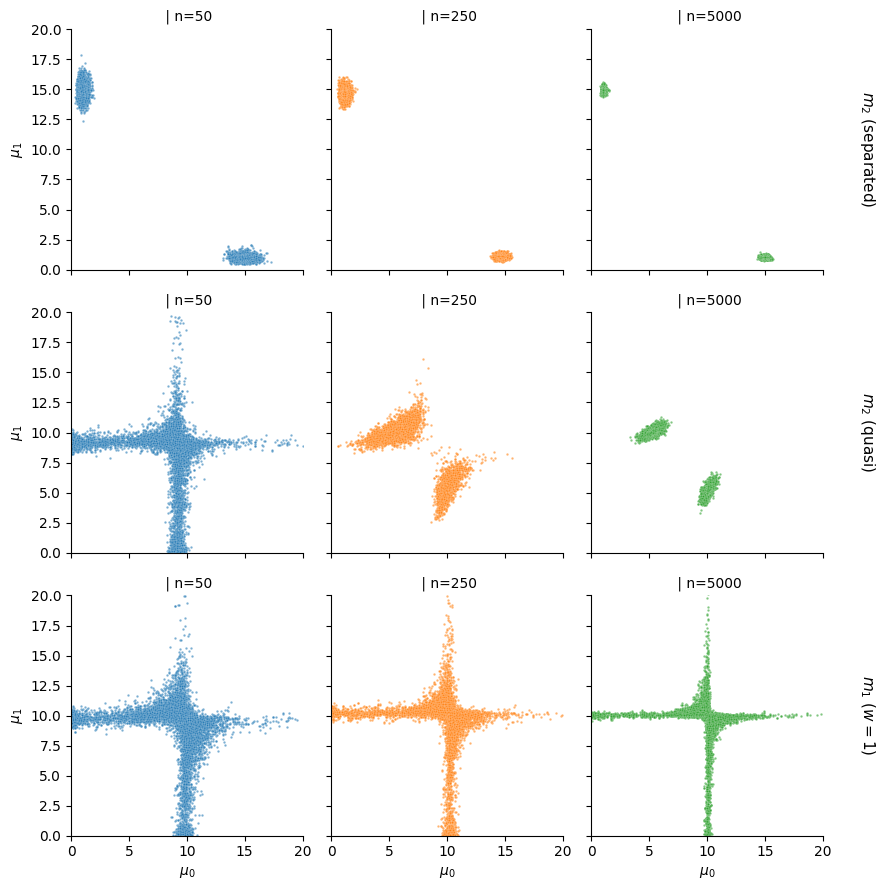

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ (separated)',
    'e-singular': r'$m_2$ (quasi)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($\mu_1=\mu_2$)',
}

# Use seaborn's default palette
default_palette = sns.color_palette()
n_palette = {
    50: default_palette[0],      # blue
    250: default_palette[1],     # orange
    5000: default_palette[2],    # green
}

# --- Single plot: Regular, Quasi-singular, and Singular ---
all_dsids = ['regular', 'e-singular', 'singular1']
all_df = joined_posterior_df[joined_posterior_df['dsid'].isin(all_dsids)]

# Ensure the order is correct
all_df['dsid'] = pd.Categorical(all_df['dsid'], categories=all_dsids, ordered=True)

g = sns.FacetGrid(all_df, row="dsid", col="n", height=3, aspect=1)
g.map_dataframe(lambda data, **kwargs: sns.scatterplot(data=data, x="m0", y="m1", 
                                                        color=n_palette.get(data['n'].iloc[0], 'gray'),
                                                        alpha=0.6, s=3))
g.set(xlim=(0, 20), ylim=(0, 20))
g.set_axis_labels(r"$\mu_0$", r"$\mu_1$")
g.set_titles(col_template="n={col_name}", row_template="")

# Add row labels on the right side
for i, dsid_val in enumerate(all_dsids):
    ax = g.axes[i, -1]
    ax.text(1.15, 0.5, dsid_labels.get(dsid_val, dsid_val), 
            transform=ax.transAxes, 
            rotation=270, 
            va='center', 
            fontsize=11)

# g.figure.suptitle('Posterior Geometry: Regular, Quasi-Singular, and Singular', y=1.02, fontsize=13)
plt.tight_layout()
plt.subplots_adjust(right=0.92)
plt.savefig(Path(f"{outputdir}/2d_view_all.png"), dpi=600, bbox_inches="tight")
plt.show()

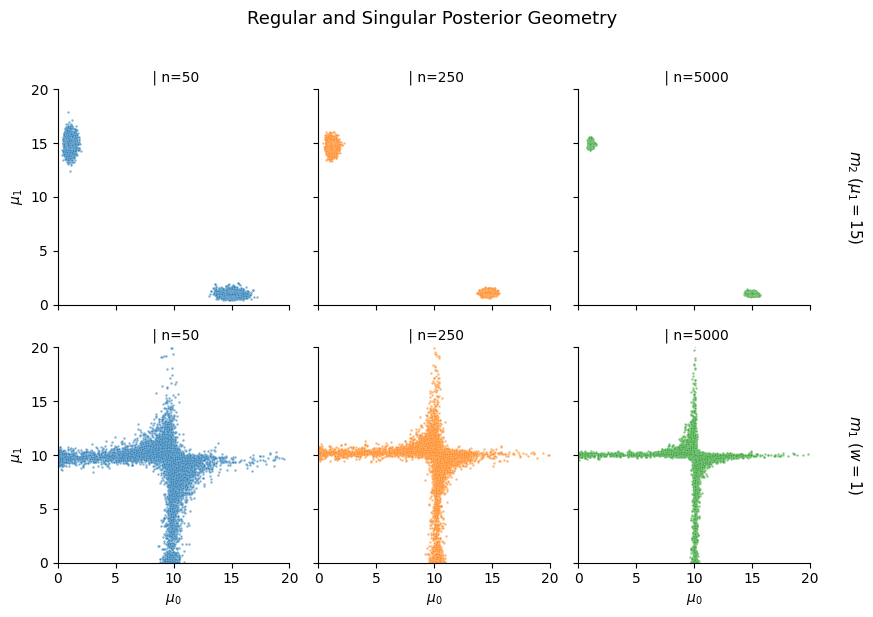

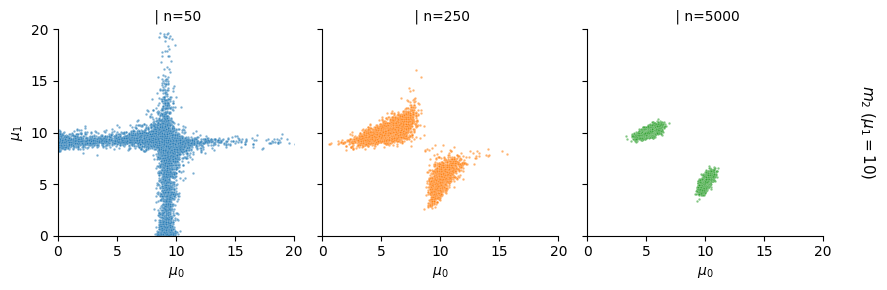

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ ($\mu_1=15$)',
    'e-singular': r'$m_2$ ($\mu_1=10$)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($\mu_1=\mu_2$)',
}

# Use seaborn's default palette
default_palette = sns.color_palette()
n_palette = {
    50: default_palette[0],      # blue
    250: default_palette[1],     # orange
    5000: default_palette[2],    # green
}

# --- Plot 1: Regular and Singular ---
reg_sing_df = joined_posterior_df[joined_posterior_df['dsid'].isin(['regular', 'singular1'])]

g1 = sns.FacetGrid(reg_sing_df, row="dsid", col="n", height=3, aspect=1)
g1.map_dataframe(lambda data, **kwargs: sns.scatterplot(data=data, x="m0", y="m1", 
                                                         color=n_palette.get(data['n'].iloc[0], 'gray'),
                                                         alpha=0.6, s=3))
g1.set(xlim=(0, 20), ylim=(0, 20))
g1.set_axis_labels(r"$\mu_0$", r"$\mu_1$")
g1.set_titles(col_template="n={col_name}", row_template="")

# Add row labels on the right side
for i, dsid_val in enumerate(g1.row_names):
    ax = g1.axes[i, -1]
    ax.text(1.15, 0.5, dsid_labels.get(dsid_val, dsid_val), 
            transform=ax.transAxes, 
            rotation=270, 
            va='center', 
            fontsize=11)

g1.figure.suptitle('Regular and Singular Posterior Geometry', y=1.02, fontsize=13)
plt.tight_layout()
plt.subplots_adjust(right=0.92)
plt.savefig(Path(f"{outputdir}/2d_view_reg_sing.png"), dpi=600, bbox_inches="tight")
plt.show()


# --- Plot 2: Quasi-singular ---
quasi_df = joined_posterior_df[joined_posterior_df['dsid'].isin(['e-singular'])]

g2 = sns.FacetGrid(quasi_df, row="dsid", col="n", height=3, aspect=1)
g2.map_dataframe(lambda data, **kwargs: sns.scatterplot(data=data, x="m0", y="m1", 
                                                         color=n_palette.get(data['n'].iloc[0], 'gray'),
                                                         alpha=0.6, s=3))
g2.set(xlim=(0, 20), ylim=(0, 20))
g2.set_axis_labels(r"$\mu_0$", r"$\mu_1$")
g2.set_titles(col_template="n={col_name}", row_template="")

# Add row label on the right side
for i, dsid_val in enumerate(g2.row_names):
    ax = g2.axes[i, -1]
    ax.text(1.15, 0.5, dsid_labels.get(dsid_val, dsid_val), 
            transform=ax.transAxes, 
            rotation=270, 
            va='center', 
            fontsize=11)

# g2.figure.suptitle('Quasi-Singular Posterior Geometry', y=1.02, fontsize=13)
plt.tight_layout()
plt.subplots_adjust(right=0.92)
plt.savefig(Path(f"{outputdir}/2d_view_quasi.png"), dpi=600, bbox_inches="tight")
plt.show()

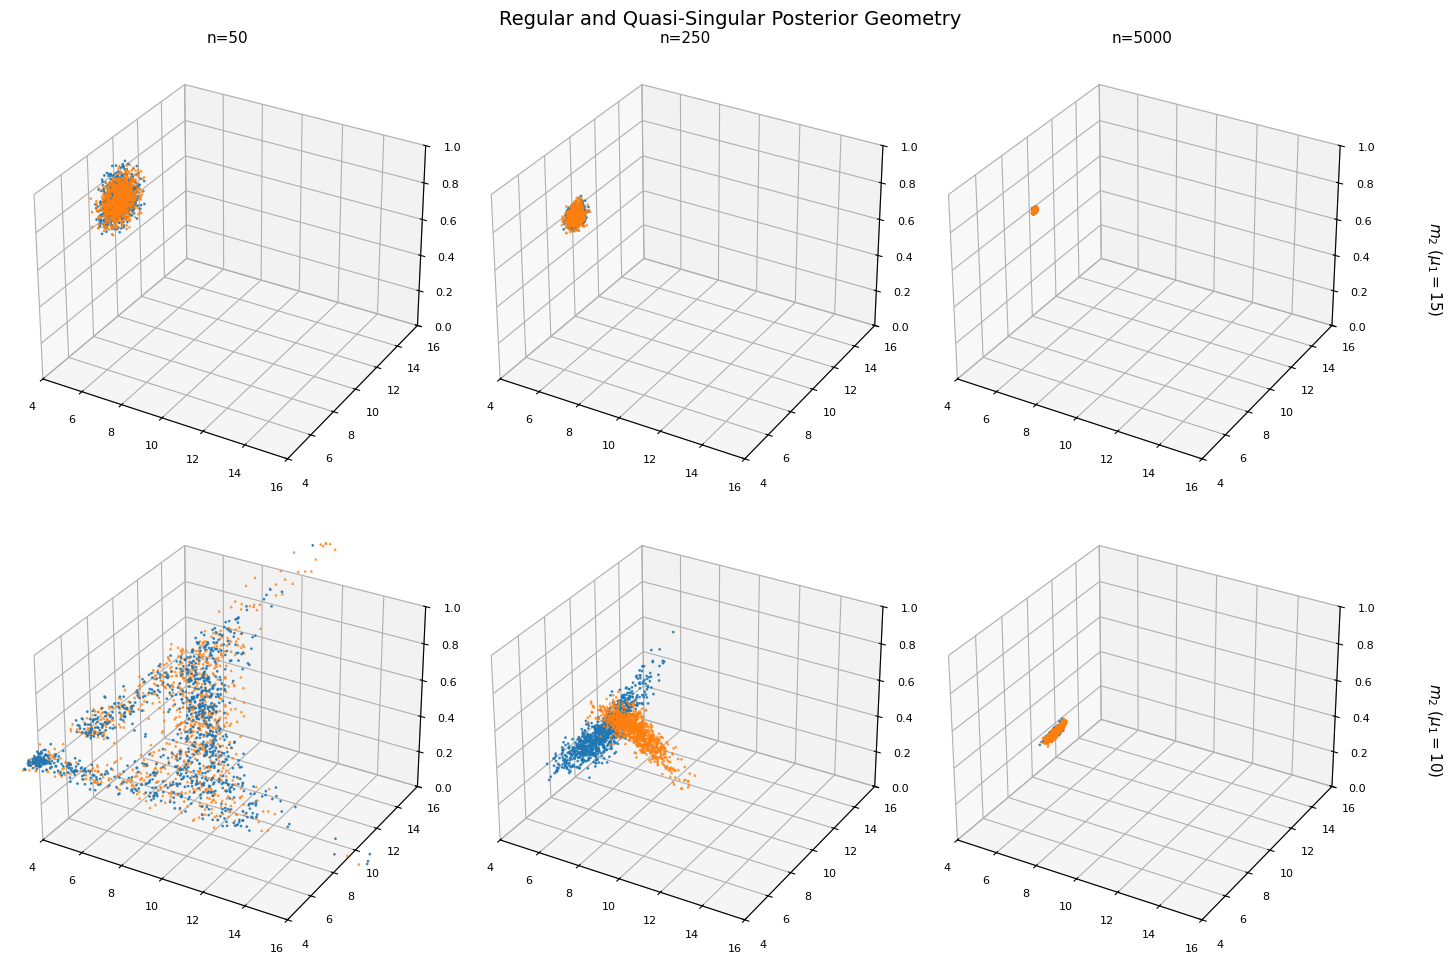

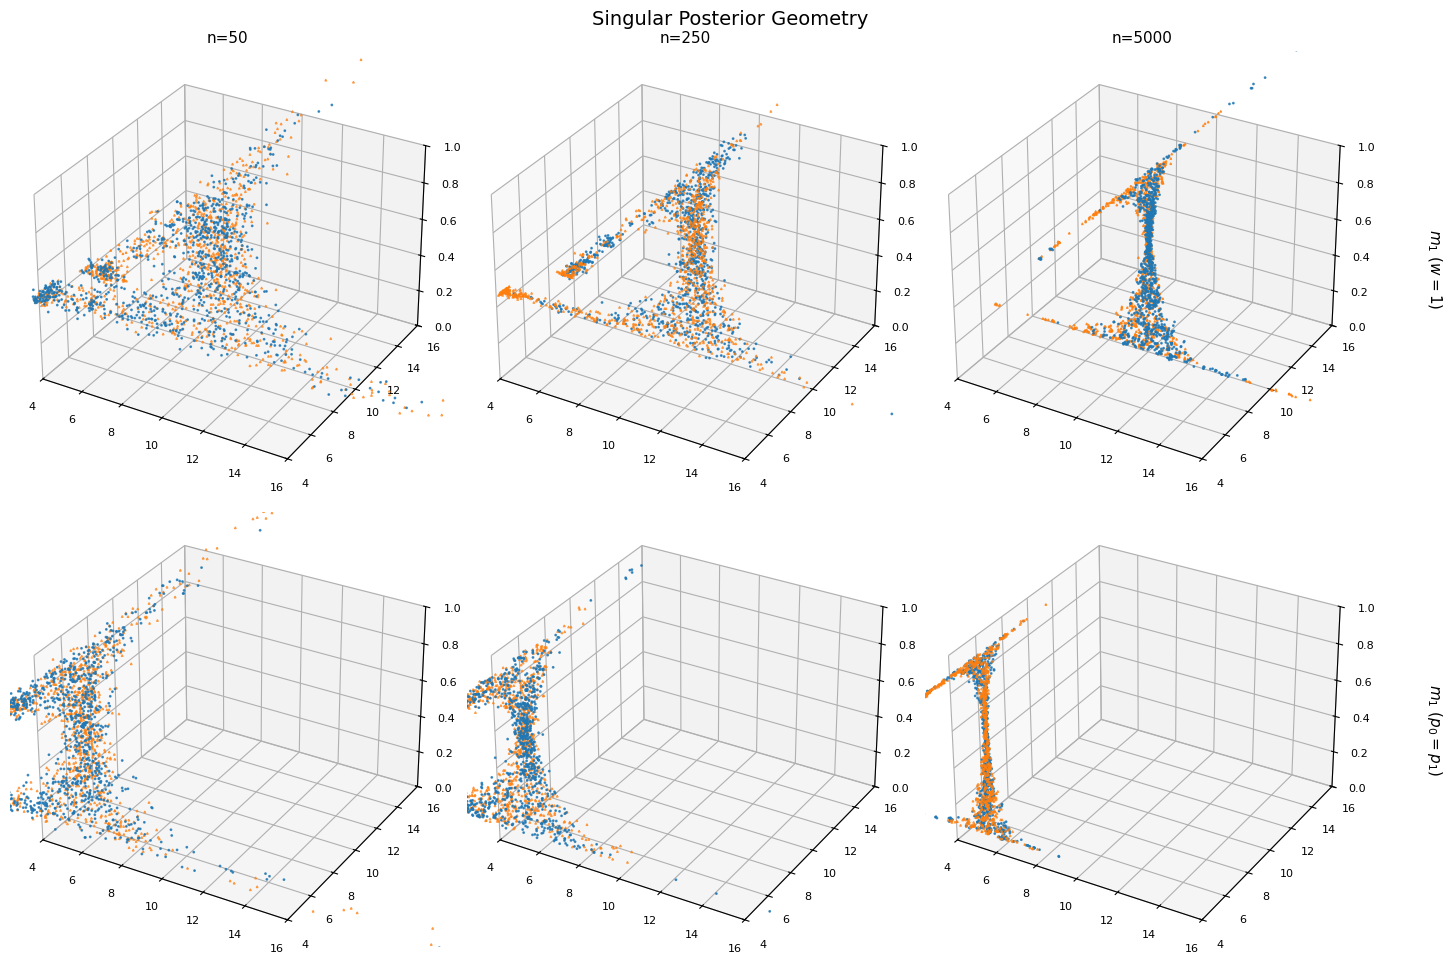

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ ($\mu_1=15$)',
    'e-singular': r'$m_2$ ($\mu_1=10$)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($p_0=p_1$)',
}

# Choose which beta to plot (e.g., beta=1 for untempered)
plot_beta = 1  # or list(tempered_posterior_data['regular'][regimes[0]].keys())[0]

n_regimes = len(regimes)

# --- Plot 1: Regular and Quasi-singular ---
quasi_dsids = ['regular', 'e-singular']
quasi_dsids = [d for d in quasi_dsids if d in tempered_posterior_data]

fig1, axes1 = plt.subplots(len(quasi_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(quasi_dsids)), 
                            subplot_kw={'projection': '3d'})
if len(quasi_dsids) == 1:
    axes1 = axes1.reshape(1, -1)

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

markers = ['o', '^', '.', '+']

for i, dsid in enumerate(quasi_dsids):
    for j, regime in enumerate(regimes):
        idata = tempered_posterior_data[dsid][regime][plot_beta]
        n_chains = idata.posterior.sizes["chain"]
        
        for chain in range(n_chains):
            w = idata.posterior["weights"][chain, :, 0]
            p0 = idata.posterior["mus"][chain, :, 0]
            p1 = idata.posterior["mus"][chain, :, 1]
            axes1[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
        
        # Zoom in
        axes1[i, j].set_xlim(4, 16)
        axes1[i, j].set_ylim(4, 16)
        axes1[i, j].set_zlim(0, 1)
        
        # Original default angle
        axes1[i, j].view_init(elev=30, azim=-60)
        
        axes1[i, j].tick_params(labelsize=8)
        
        # Column titles only on top row
        if i == 0:
            axes1[i, j].set_title(f'n={regime}', fontsize=11)

# Add row labels on the right side
for i, dsid in enumerate(quasi_dsids):
    ax = axes1[i, -1]
    ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
              transform=ax.transAxes, 
              rotation=270, 
              va='center', 
              fontsize=11)

fig1.suptitle('Regular and Quasi-Singular Posterior Geometry', fontsize=14, y=0.96)
fig1.savefig(Path(f"{outputdir}/3d_view_quasi.png"), dpi=600, bbox_inches="tight")
plt.show()


# --- Plot 2: Singular models ---
singular_dsids = ['singular1', 'singular2']
singular_dsids = [d for d in singular_dsids if d in tempered_posterior_data]

if singular_dsids:
    fig2, axes2 = plt.subplots(len(singular_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(singular_dsids)), 
                                subplot_kw={'projection': '3d'})
    if len(singular_dsids) == 1:
        axes2 = axes2.reshape(1, -1)

    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

    for i, dsid in enumerate(singular_dsids):
        for j, regime in enumerate(regimes):
            idata = tempered_posterior_data[dsid][regime][plot_beta]
            n_chains = idata.posterior.sizes["chain"]
            
            for chain in range(n_chains):
                w = idata.posterior["weights"][chain, :, 0]
                p0 = idata.posterior["mus"][chain, :, 0]
                p1 = idata.posterior["mus"][chain, :, 1]
                axes2[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
            
            # Zoom in
            axes2[i, j].set_xlim(4, 16)
            axes2[i, j].set_ylim(4, 16)
            axes2[i, j].set_zlim(0, 1)
            
            # Original default angle
            axes2[i, j].view_init(elev=30, azim=-60)
            
            axes2[i, j].tick_params(labelsize=8)
            
            # Column titles only on top row
            if i == 0:
                axes2[i, j].set_title(f'n={regime}', fontsize=11)

    # Add row labels on the right side
    for i, dsid in enumerate(singular_dsids):
        ax = axes2[i, -1]
        ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
                  transform=ax.transAxes, 
                  rotation=270, 
                  va='center', 
                  fontsize=11)

    fig2.suptitle('Singular Posterior Geometry', fontsize=14, y=0.96)
    fig2.savefig(Path(f"{outputdir}/3d_view_singular.png"), dpi=600, bbox_inches="tight")
    plt.show()

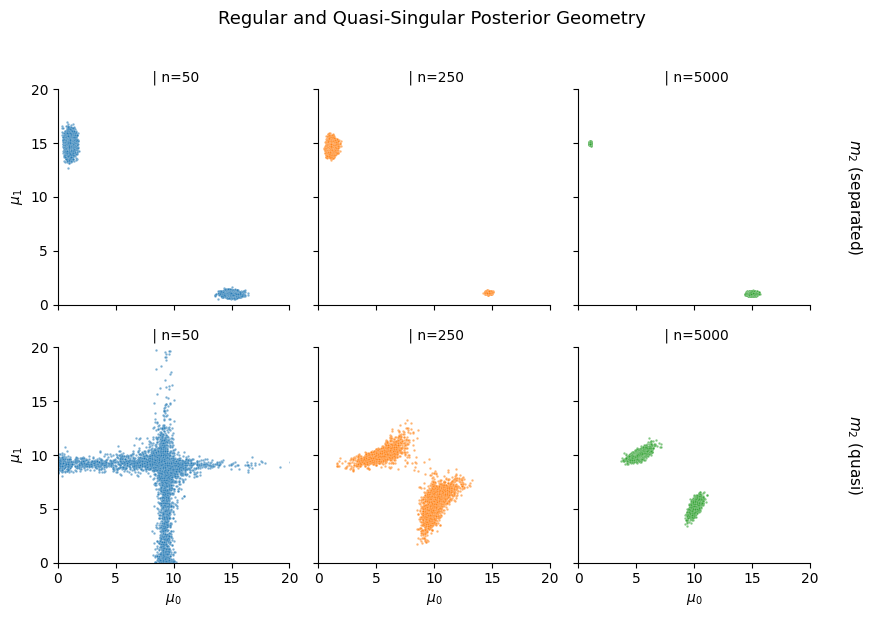

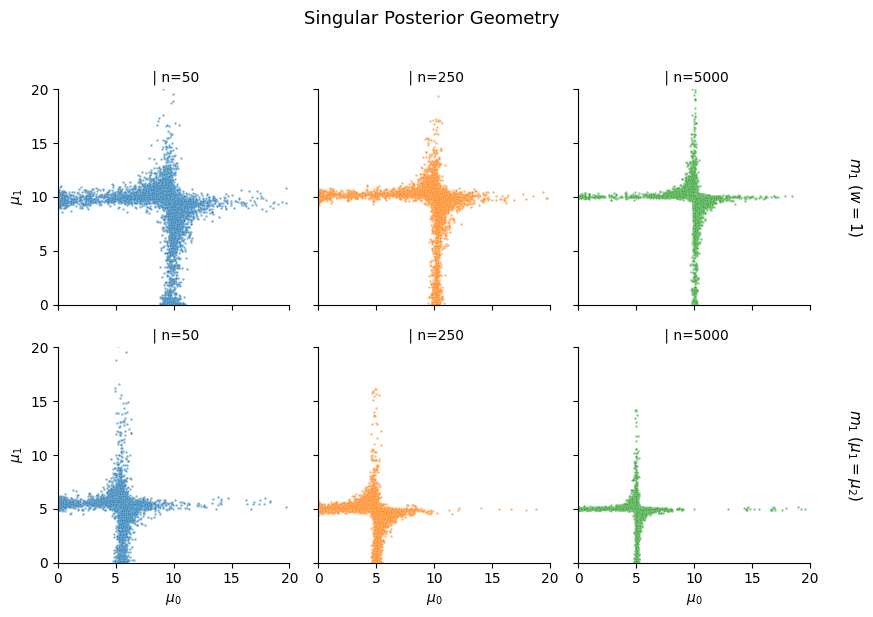

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ (separated)',
    'e-singular': r'$m_2$ (quasi)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($\mu_1=\mu_2$)',
}

# Use seaborn's default palette (same as hue uses)
default_palette = sns.color_palette()
n_palette = {
    50: default_palette[0],      # blue
    250: default_palette[1],     # orange
    5000: default_palette[2],    # green
}

# --- Plot 1: Regular and Quasi-singular ---
quasi_df = joined_posterior_df[joined_posterior_df['dsid'].isin(['regular', 'e-singular'])]

g1 = sns.FacetGrid(quasi_df, row="dsid", col="n", height=3, aspect=1)
g1.map_dataframe(lambda data, **kwargs: sns.scatterplot(data=data, x="m0", y="m1", 
                                                         color=n_palette.get(data['n'].iloc[0], 'gray'),
                                                         alpha=0.6, s=3))
g1.set(xlim=(0, 20), ylim=(0, 20))
g1.set_axis_labels(r"$\mu_0$", r"$\mu_1$")
g1.set_titles(col_template="n={col_name}", row_template="")

# Add row labels on the right side
for i, dsid_val in enumerate(g1.row_names):
    ax = g1.axes[i, -1]
    ax.text(1.15, 0.5, dsid_labels.get(dsid_val, dsid_val), 
            transform=ax.transAxes, 
            rotation=270, 
            va='center', 
            fontsize=11)

g1.figure.suptitle('Regular and Quasi-Singular Posterior Geometry', y=1.02, fontsize=13)
plt.tight_layout()
plt.subplots_adjust(right=0.92)
plt.savefig(Path(f"{outputdir}/2d_view_quasi.png"), dpi=600, bbox_inches="tight")
plt.show()


# --- Plot 2: Singular models ---
singular_dsids = ['singular1', 'singular2']
singular_df = joined_posterior_df[joined_posterior_df['dsid'].isin(singular_dsids)]

if len(singular_df) > 0:
    g2 = sns.FacetGrid(singular_df, row="dsid", col="n", height=3, aspect=1)
    g2.map_dataframe(lambda data, **kwargs: sns.scatterplot(data=data, x="m0", y="m1", 
                                                             color=n_palette.get(data['n'].iloc[0], 'gray'),
                                                             alpha=0.6, s=3))
    g2.set(xlim=(0, 20), ylim=(0, 20))
    g2.set_axis_labels(r"$\mu_0$", r"$\mu_1$")
    g2.set_titles(col_template="n={col_name}", row_template="")

    # Add row labels on the right side
    for i, dsid_val in enumerate(g2.row_names):
        ax = g2.axes[i, -1]
        ax.text(1.15, 0.5, dsid_labels.get(dsid_val, dsid_val), 
                transform=ax.transAxes, 
                rotation=270, 
                va='center', 
                fontsize=11)

    g2.figure.suptitle('Singular Posterior Geometry', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.subplots_adjust(right=0.92)
    plt.savefig(Path(f"{outputdir}/2d_view_singular.png"), dpi=600, bbox_inches="tight")
    plt.show()

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ ($\mu_1=15$)',
    'e-singular': r'$m_2$ ($\mu_1=10$)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($p_0=p_1$)',
}

# Get regime names (sample sizes)
regime_names = list(list(posterior_data.values())[0].keys())
n_regimes = len(regime_names)

# --- Plot 1: Regular and Quasi-singular ---
quasi_dsids = ['regular', 'e-singular']
quasi_dsids = [d for d in quasi_dsids if d in posterior_data]

fig1, axes1 = plt.subplots(len(quasi_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(quasi_dsids)), 
                            subplot_kw={'projection': '3d'})
if len(quasi_dsids) == 1:
    axes1 = axes1.reshape(1, -1)

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

markers = ['o', '^', '.', '+']

for i, dsid in enumerate(quasi_dsids):
    for j, regime in enumerate(regime_names):
        idata = posterior_data[dsid][regime]
        n_chains = idata.posterior.sizes["chain"]
        
        for chain in range(n_chains):
            w = idata.posterior["weights"][chain, :, 0]
            p0 = idata.posterior["mus"][chain, :, 0]
            p1 = idata.posterior["mus"][chain, :, 1]
            axes1[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
        
        # Zoom in
        axes1[i, j].set_xlim(4, 16)
        axes1[i, j].set_ylim(4, 16)
        axes1[i, j].set_zlim(0, 1)
        
        # Original default angle
        axes1[i, j].view_init(elev=30, azim=-60)
        
        axes1[i, j].tick_params(labelsize=8)
        
        # Column titles only on top row
        if i == 0:
            axes1[i, j].set_title(f'n={regime}', fontsize=11)

# Add row labels on the right side
for i, dsid in enumerate(quasi_dsids):
    ax = axes1[i, -1]
    ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
              transform=ax.transAxes, 
              rotation=270, 
              va='center', 
              fontsize=11)

fig1.suptitle('Regular and Quasi-Singular Posterior Geometry', fontsize=14, y=0.96)
fig1.savefig(Path(f"{outputdir}/3d_view_quasi.png"), dpi=600, bbox_inches="tight")
plt.show()


# --- Plot 2: Singular models ---
singular_dsids = ['singular1', 'singular2']
singular_dsids = [d for d in singular_dsids if d in posterior_data]

if singular_dsids:
    fig2, axes2 = plt.subplots(len(singular_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(singular_dsids)), 
                                subplot_kw={'projection': '3d'})
    if len(singular_dsids) == 1:
        axes2 = axes2.reshape(1, -1)

    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

    for i, dsid in enumerate(singular_dsids):
        for j, regime in enumerate(regime_names):
            idata = posterior_data[dsid][regime]
            n_chains = idata.posterior.sizes["chain"]
            
            for chain in range(n_chains):
                w = idata.posterior["weights"][chain, :, 0]
                p0 = idata.posterior["mus"][chain, :, 0]
                p1 = idata.posterior["mus"][chain, :, 1]
                axes2[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
            
            # Zoom in
            axes2[i, j].set_xlim(4, 16)
            axes2[i, j].set_ylim(4, 16)
            axes2[i, j].set_zlim(0, 1)
            
            # Original default angle
            axes2[i, j].view_init(elev=30, azim=-60)
            
            axes2[i, j].tick_params(labelsize=8)
            
            # Column titles only on top row
            if i == 0:
                axes2[i, j].set_title(f'n={regime}', fontsize=11)

    # Add row labels on the right side
    for i, dsid in enumerate(singular_dsids):
        ax = axes2[i, -1]
        ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
                  transform=ax.transAxes, 
                  rotation=270, 
                  va='center', 
                  fontsize=11)

    fig2.suptitle('Singular Posterior Geometry', fontsize=14, y=0.96)
    fig2.savefig(Path(f"{outputdir}/3d_view_singular.png"), dpi=600, bbox_inches="tight")
    plt.show()

NameError: name 'posterior_data' is not defined

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_53523/2071673554.py:18: SyntaxWarning: invalid escape sequence '\m'
  g1.set_axis_labels("$\mu_0$", "$\mu_1$")
/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_53523/2071673554.py:18: SyntaxWarning: invalid escape sequence '\m'
  g1.set_axis_labels("$\mu_0$", "$\mu_1$")
/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_53523/2071673554.py:44: SyntaxWarning: invalid escape sequence '\m'
  g2.set_axis_labels("$\mu_0$", "$\mu_1$")
/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_53523/2071673554.py:44:

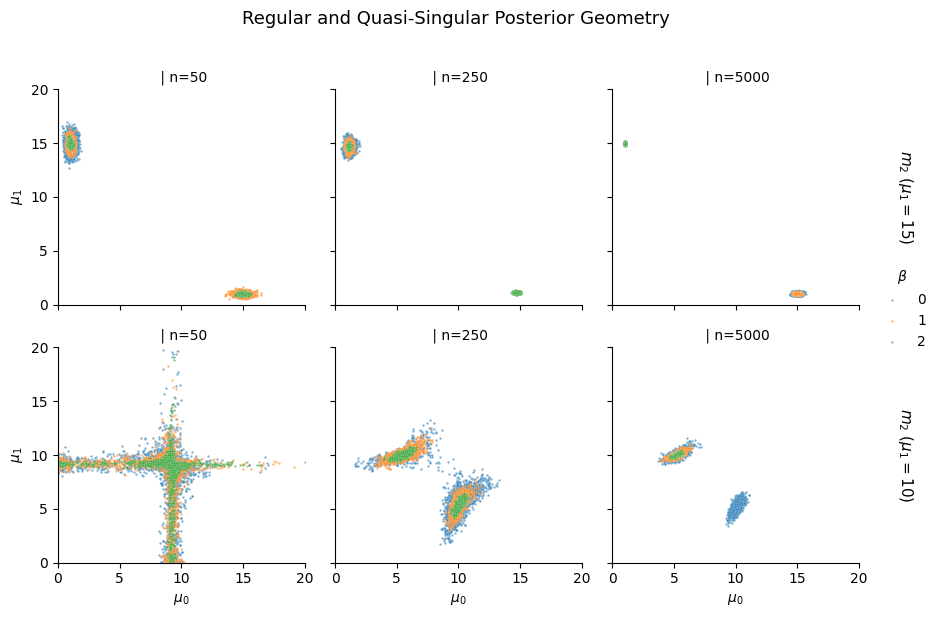

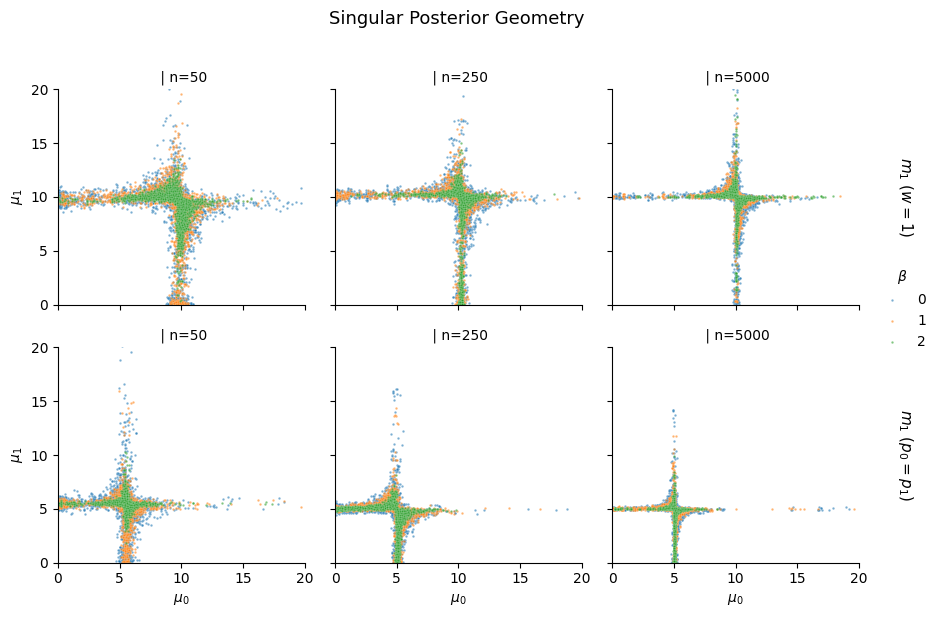

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ ($\mu_1=15$)',
    'e-singular': r'$m_2$ ($\mu_1=10$)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($p_0=p_1$)',  # Added in case you have this
}

# --- Plot 1: Regular and E-singular (Quasi-singular) ---
quasi_df = joined_posterior_df[joined_posterior_df['dsid'].isin(['regular', 'e-singular'])]

g1 = sns.FacetGrid(quasi_df, row="dsid", col="n", hue='ibeta', height=3, aspect=1)
g1.map(sns.scatterplot, "m0", "m1", alpha=0.6, s=3)
g1.set(xlim=(0, 20), ylim=(0, 20))
g1.set_axis_labels("$\mu_0$", "$\mu_1$")
g1.set_titles(col_template="n={col_name}", row_template="")

# Add row labels on the right side
for i, dsid_val in enumerate(g1.row_names):
    ax = g1.axes[i, -1]
    ax.text(1.15, 0.5, dsid_labels.get(dsid_val, dsid_val), 
            transform=ax.transAxes, 
            rotation=270, 
            va='center', 
            fontsize=11)

g1.figure.suptitle("Regular and Quasi-Singular Posterior Geometry", y=1.02, fontsize=13)
plt.tight_layout()
g1.add_legend(title=r"$\beta$")
plt.subplots_adjust(right=0.92)
plt.savefig(Path(f"{outputdir}/tempered-poisson2d-quasi.png"), dpi=600, bbox_inches="tight")
plt.show()

# --- Plot 2: Singular models ---
singular_dsids = ['singular1', 'singular2'] if 'singular2' in joined_posterior_df['dsid'].values else ['singular1']
singular_df = joined_posterior_df[joined_posterior_df['dsid'].isin(singular_dsids)]

g2 = sns.FacetGrid(singular_df, row="dsid", col="n", hue='ibeta', height=3, aspect=1)
g2.map(sns.scatterplot, "m0", "m1", alpha=0.6, s=3)
g2.set(xlim=(0, 20), ylim=(0, 20))
g2.set_axis_labels("$\mu_0$", "$\mu_1$")
g2.set_titles(col_template="n={col_name}", row_template="")

# Add row labels on the right side
for i, dsid_val in enumerate(g2.row_names):
    ax = g2.axes[i, -1]
    ax.text(1.15, 0.5, dsid_labels.get(dsid_val, dsid_val), 
            transform=ax.transAxes, 
            rotation=270, 
            va='center', 
            fontsize=11)

g2.figure.suptitle("Singular Posterior Geometry", y=1.02, fontsize=13)
plt.tight_layout()
g2.add_legend(title=r"$\beta$")
plt.subplots_adjust(right=0.92)
plt.savefig(Path(f"{outputdir}/tempered-poisson2d-singular.png"), dpi=600, bbox_inches="tight")
plt.show()

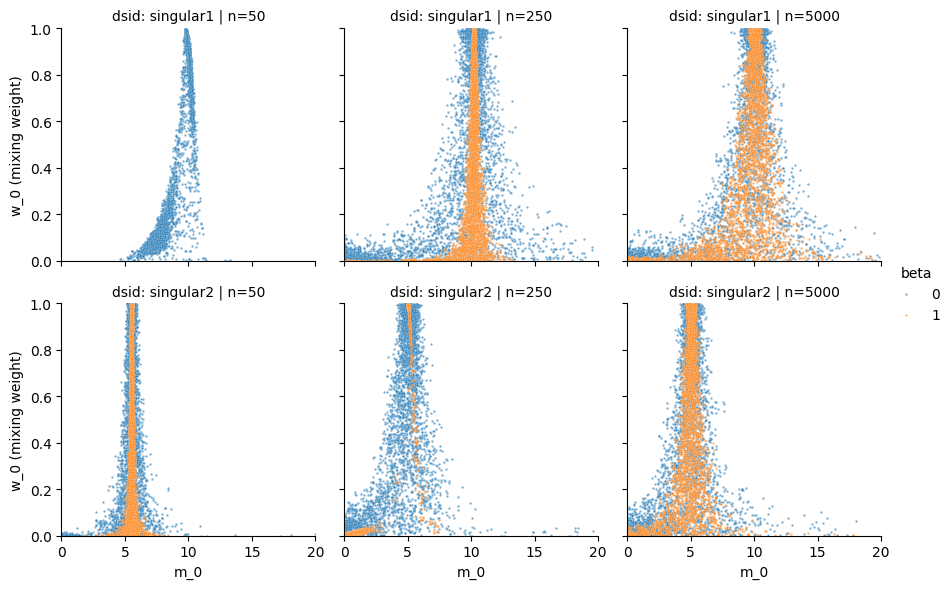

In [9]:
import seaborn as sns
# Create FacetGrid
g = sns.FacetGrid(joined_posterior_df, row="dsid", col="n", hue="ibeta", height=3, aspect=1)

# Map scatter plot
g.map(sns.scatterplot, "m0", "w0", alpha=0.6, s=3)

# Set axis limits
g.set(xlim=(0, 20), ylim=(0, 1))
# Add labels and formatting
g.set_axis_labels("m_0", "w_0 (mixing weight)")
g.set_titles(row_template="dsid: {row_name}", col_template="n={col_name}")

plt.tight_layout()
g.add_legend(title="beta")
plt.show()

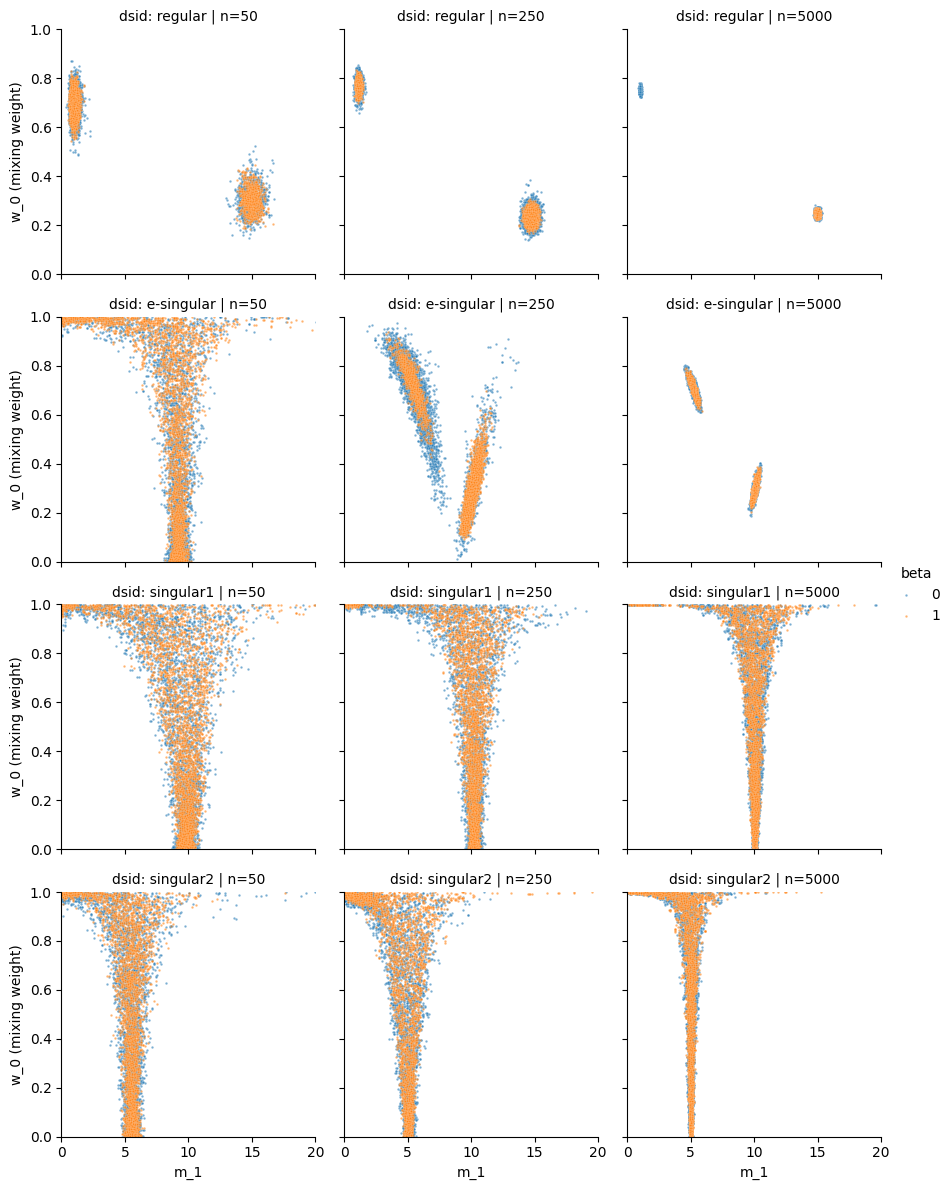

In [10]:
import seaborn as sns
# Create FacetGrid
g = sns.FacetGrid(joined_posterior_df, row="dsid", col="n", hue="ibeta", height=3, aspect=1)

# Map scatter plot
g.map(sns.scatterplot, "m1", "w0", alpha=0.6, s=3)

# Set axis limits
g.set(xlim=(0, 20), ylim=(0, 1))
# Add labels and formatting
g.set_axis_labels("m_1", "w_0 (mixing weight)")
g.set_titles(row_template="dsid: {row_name}", col_template="n={col_name}")

plt.tight_layout()
g.add_legend(title="beta")
plt.show()

In [22]:
def clean_for_plotting(
    arr, method="percentile", threshold=1000, percentile=95, handle_nan=True, clip=True
):
    """
    Universal cleaning function for plotting

    Parameters:
    -----------
    arr : array-like
    method : 'percentile' or 'threshold'
        How to determine replacement values
    threshold : float
        For 'threshold' method: distance from min/max
    percentile : float
        For 'percentile' method: which percentile to use
    handle_nan : bool
        Whether to replace NaN
    clip : bool
        Whether to clip to [min, max] range
    """
    arr = np.asarray(arr, dtype=float).copy()

    finite_mask = np.isfinite(arr)

    if not np.any(finite_mask):
        return np.zeros_like(arr)

    finite_values = arr[finite_mask]

    if method == "percentile":
        low_val = np.percentile(finite_values, 100 - percentile)
        high_val = np.percentile(finite_values, percentile)
        value_range = high_val - low_val
        margin = max(value_range * 0.1, abs(high_val) * 0.01, 1.0)
        replacement_low = low_val - margin
        replacement_high = high_val + margin
    else:  # threshold
        finite_min = finite_values.min()
        finite_max = finite_values.max()
        replacement_low = finite_min - threshold
        replacement_high = finite_max + threshold

    # Replace infinities
    arr = np.where(np.isneginf(arr), replacement_low, arr)
    arr = np.where(np.isposinf(arr), replacement_high, arr)

    if handle_nan:
        arr = np.where(np.isnan(arr), replacement_high, arr)

    if clip:
        arr = np.clip(arr, replacement_low, replacement_high)

    return arr

In [18]:
def plot_kl_contours(data_df, profile_kl, plot_options={}, profile_options={}):
    plot_options = {
        "quantiles": np.array(
            [
                0.01,
                0.02,
                0.03,
                0.04,
                0.05,
                0.075,
                0.9,
                0.1,
                0.2,
                0.3,
                0.4,
                0.5,
                0.6,
                0.7,
                0.8,
                0.9,
                0.99,
            ]
        ),
        # "colors": ['#808080', '#A0A0A0', '#C0C0C0'],
        "figsize": (16, 6),
        "linewidths": 2.0,
        "cmap": "magma",
        "line_colors": "black",
        "label_fontsize": 1000,
    } | plot_options

    profile_options = {"grid_size": 100} | profile_options

    # Get unique values for facets
    dsids = data_df["dsid"].unique()
    n_obs_list = sorted(data_df["n"].unique())

    n_rows = len(dsids)
    n_cols = len(n_obs_list)

    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10), sharex=True, sharey=True)

    # Plot each panel
    for i, dsid in enumerate(tqdm(dsids, desc=f"datasets ")):
        # for i, dsid in enumerate(dsids):
        dgp = dgps.query(f"dsid=='{dsid}'")
        truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
        height = profile_kl(
            n_components=n_components,
            n_trials=n_trials,
            truth=truth,
            x_param={"name": "probs", "index": 0},
            y_param={"name": "probs", "index": 1},
            profile_grid_size=profile_options["grid_size"],
        )

        for j, n in enumerate(tqdm(sample_sizes, desc=f"{dsid} figures")):
            ax = axes[i, j]

            # Filter data for this combination
            subset = mles_df[(mles_df["dsid"] == dsid) & (mles_df["n"] == n)]

            # 1. computed profile KL values
            x = np.linspace(0, 1, 50)
            y = np.linspace(0, 1, 50)
            X, Y = np.meshgrid(x, y)
            Z = height(X, Y)

            # compoute contour levels for the quantiles
            # Z = clean_for_plotting(height(X,Y), method='percentile', percentile=0.999)
            levels = np.unique(np.quantile(Z, plot_options["quantiles"]))

            # align contours with levels
            n_levels = len(levels)
            cmap = plt.get_cmap("YlOrRd")
            colors = [cmap(q) for q in np.linspace(0, 1, n_levels)]

            cs = ax.contourf(
                X, Y, Z, levels=levels, colors=colors, alpha=0.8, extend="both"
            )
            cs_lines = ax.contour(X, Y, Z, levels=levels, colors="black", linewidths=1)
            # Create a dictionary mapping each level to its corresponding quantile value
            fmt = {}
            for l, level in enumerate(levels):
                if l < len(plot_options["quantiles"]):
                    # Just show the quantile value (e.g., "0.95")
                    fmt[level] = f"{plot_options['quantiles'][l]:.2f}"

            # Apply the custom labels
            ax.clabel(
                cs_lines,
                fontsize=6,
                inline=True,
                fmt=fmt,
                inline_spacing=10,
                colors="black",
                use_clabeltext=True,
            )

            # Scatter plot
            sns.scatterplot(data=subset, x="p0", y="p1", ax=ax, alpha=1, s=5)

            # Add title
            if i == 0:
                ax.set_title(f"n={n}", fontweight="bold")
            if j == 0:
                ax.set_ylabel(f"dsid: {dsid}\np_0", fontweight="bold")
            else:
                ax.set_ylabel("p_1")

            if i == n_rows - 1:
                ax.set_xlabel("p_0")
            else:
                ax.set_xlabel("")
            # break
        # break
    return fig, axes


fig, axes = plot_kl_contours(
    mles_df, profile_kl=create_mixbinom_profile_kl, profile_options={"grid_size": 20}
)

plt.tight_layout()
fig.savefig(Path(f"{basedir}/mle/mles_with_kl.png"), dpi=600, bbox_inches="tight")
plt.show()

NameError: name 'mles_df' is not defined